# Functional Capstone Project - Data & Analytics



## Business Context

**Infini Telco** is a prominent player in the telco industry with a strong presence in Malaysia. Specializing in B2B sales, they serve as a vital link in the supply chain, facilitating the distribution of telecommunication and technology products to retailers, service providers, and other businesses across the continent.

Despite their market dominance and expansive product offerings, the company faces critical business challenge related to marketing strategy. A key aspect of this involves the ***identification and segmentation of their customer base into well-defined segments based on discernible patterns in product purchase behaviour and understand their product portfolio.*** By understanding the distinct needs, preferences, and purchasing habits of different customer segments, the client can develop targeted marketing strategies that cater to the specific needs of each segment, enhancing customer satisfaction and loyalty, driving revenue growth.




## Business Challenges

- No streamlined process to handle data and data is only available in chunks
- Limited intel on customer purchase patterns to drive targeted marketing
- Inadequate product insights across different customer groups


## Project Objectives

The business needs your help as a ***data analyst*** to overcome these challenges. Apply your data analytics skillset learnt.



### 1. Data Preprocessing

Data preparation is a critical process first step, involving the gathering, cleaning, transforming, and organizing of raw data into a format suitable for analysis. This step is essential for ensuring the quality and reliability of the insights derived from the data.

Here, the transaction data is provided from June 2020 to December 2022, which are stored across three separate csv files. The dataset are:

- Transactions_1.csv
- Transactions_2.csv
- Transactions_3.csv

***Task 1.1: Combine the transaction data files***

Find a way to combine the above data together into a singular dataframe, that will contain all the transactions at one place. Name this singular dataframe df_Txn_full.

In [1]:
#Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 100

In [2]:
# Import transaction file 1
file1 = pd.read_csv('Transactions_1.csv')
file1.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,000000000000100095,ZSV,0.00,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1


In [3]:
# Import transaction file 2
file2 = pd.read_csv('Transactions_2.csv')
file2.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT
0,124526,124289549,50,2022-10-01,23388,23388,Customer Group_283,Responsible Employee_15,000000000000100095,ZSV,0.00,0
1,124532,124289549,210,2022-10-01,23388,23388,Customer Group_283,Responsible Employee_15,000000000000100095,ZSV,0.00,0
2,124541,124289549,130,2022-10-01,23388,23388,Customer Group_283,Responsible Employee_15,000000000000100095,ZSV,0.00,0
3,124543,124289549,290,2022-10-01,23388,23388,Customer Group_283,Responsible Employee_15,000000000000100095,ZSV,0.00,1
4,124558,124289549,10,2022-10-01,23388,23388,Customer Group_283,Responsible Employee_15,000000000000100095,ZSV,0.00,0


In [4]:
# Import transaction file 3
file3 = pd.read_csv('Transactions_3.csv')

# Combine all transaction files
df_Transaction = pd.concat([file1, file2, file3], ignore_index=True)

# Preview
print(df_Transaction.shape)
df_Transaction.head()

(1353671, 12)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,000000000000100095,ZSV,0.00,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1


**Validation checkpoints:**
Consider, you would have received some information from the business on:

- Gross Annual Turnover for this period to be ~$1.4B
- The total unique products are ~190000
- The total customer base is ~7k

***Task 1.1.1***:

Use the above information to validate the data creation process. This is to ensure that no records of data are lost in the process.

In [5]:
# Gross Annual Turnover
print('Gross Annual Turnover:', df_Transaction['GROSS_TURNOVER'].sum())

# Total unique products
print('Unique Products:', df_Transaction['PRODUCT'].nunique())

# Total customer base
print('Customer Base:', df_Transaction['CUSTOMER_NUMBER'].nunique())

Gross Annual Turnover: 1466478196.7234998
Unique Products: 191394
Customer Base: 7130


***Task 1.2: Join the mapping files to the transaction data***


Mapping files contain supplementary detailed information that will be used for our analysis.
Use these mapping files to join with the above transaction data to create the master dataset <br><br>
**List of mapping files and their primary keys:**<br>
1. Customer Characteristics : to be joined on Customer Number
2. Customer Type Mapping : to be joined on Main Account ID
3. Product Category Mapping : to be joined on Product ID

To ensure that the joins are performed accurately, it is a good practice to clean up the columns upon which the join is performed.
Some recommended steps to clean up a column are:

- ensuring the values are of the same data type
- removing leading zeroes
- removing leading and trailing whitespaces etc.


***Task 1.2.1:***

Here, before, performing the joins, you have to perform an intermediary step to clean up the below columns based on the above recommended steps:

- customer_number
- Product
- Main_account
- Invoice_Number

*Hint: Check for any leading or trailing 0s or white spaces.*

In [6]:
import pandas as pd

# Standardize transaction keys
def standardize_col(col):
    return col.astype(str).str.strip().str.lstrip('0').str.upper()

df_Transaction['CUSTOMER_NUMBER'] = standardize_col(df_Transaction['CUSTOMER_NUMBER'])
df_Transaction['PRODUCT'] = standardize_col(df_Transaction['PRODUCT'])
df_Transaction['Main_account'] = standardize_col(df_Transaction['Main_account'])
df_Transaction['INVOICE_NUMBER'] = standardize_col(df_Transaction['INVOICE_NUMBER'])

print("Transaction columns standardized.")

Transaction columns standardized.


In [7]:
df_Transaction['CUSTOMER_NUMBER'] = df_Transaction['CUSTOMER_NUMBER'].str.lstrip('0')

# Check result
df_Transaction['CUSTOMER_NUMBER'].head()

,CUSTOMER_NUMBER
0,14816
1,17566
2,17566
3,17566
4,17566


***Task 1.2.2:***

Import the mapping files and rename the dataframe:

- Customer Characteristics.csv : df_CustChar
- Customer Type Mapping.csv : df_CustType
- Product Categories.csv : df_ProdCategories

In [8]:
# Import mapping files
df_CustChar = pd.read_csv('Customer Characteristics.csv')
df_CustType = pd.read_csv('Customer Type Mapping.csv')
df_ProdCategories = pd.read_csv('Product Categories.csv', sep=None, engine='python', on_bad_lines='warn', encoding='latin1')

In [9]:
print(df_CustChar.shape)
print(df_CustType.shape)
print(df_ProdCategories.shape)

(7130, 4)
(6855, 2)
(210028, 4)


***Task 1.2.3:***

To perform join on the dataframes, it is important to clean the columns to ensure that the columns are free from any special characters.

- Remove any leading or trailing 0s in Customer_Number column in the df_CustChar dataframe.
- Check for duplicates in the data and remove any duplicates.
- Create a master dataframe by performing appropriate join on df_CustChar dataframe and df_Txn_full dataframe. Rename the master dataframe as df_Master.



In [10]:
import pandas as pd
import numpy as np

# 1. Define standardization helper function
def standardize_col(col):
    return col.astype(str).str.strip().str.lstrip('0').str.upper()

# 2. Reload mapping files to ensure they exist in memory
try:
    df_CustChar = pd.read_csv('Customer Characteristics.csv')
    df_CustType = pd.read_csv('Customer Type Mapping.csv')
    df_ProdCategories = pd.read_csv('Product Categories.csv', sep=None, engine='python', on_bad_lines='warn', encoding='latin1')

    # 3. Standardize Transaction keys
    df_Transaction['CUSTOMER_NUMBER'] = standardize_col(df_Transaction['CUSTOMER_NUMBER'])
    df_Transaction['PRODUCT'] = standardize_col(df_Transaction['PRODUCT'])
    df_Transaction['Main_account'] = standardize_col(df_Transaction['Main_account'])

    # 4. Join Customer Characteristics
    df_CustChar['CUSTOMER_NUMBER'] = standardize_col(df_CustChar['CUSTOMER_NUMBER'])
    df_CustChar = df_CustChar.drop_duplicates(subset=['CUSTOMER_NUMBER'])
    df_Master = pd.merge(df_Transaction, df_CustChar, on='CUSTOMER_NUMBER', how='left')

    # 5. Join Customer Type
    df_CustType['Main_account_ID'] = standardize_col(df_CustType['Main_account_ID'])
    df_CustType = df_CustType.drop_duplicates(subset=['Main_account_ID'])
    df_Master = pd.merge(df_Master, df_CustType, left_on='Main_account', right_on='Main_account_ID', how='left')

    # 6. Join Product Categories
    df_ProdCategories['ProductID'] = standardize_col(df_ProdCategories['ProductID'])
    df_ProdCategories = df_ProdCategories.drop_duplicates(subset=['ProductID'])
    df_Master = pd.merge(df_Master, df_ProdCategories, left_on='PRODUCT', right_on='ProductID', how='left')

    print(f"Master Dataframe successfully created. Shape: {df_Master.shape}")
    print("Preview of columns:", df_Master.columns.tolist())

except Exception as e:
    print(f"Error loading or joining data: {e}")

Master Dataframe successfully created. Shape: (1353671, 21)
Preview of columns: ['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name', 'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line', 'GROSS_TURNOVER', 'AMOUNT', 'CUSTOMER_NAME', 'ACCOUNT_GROUP_TXT', 'CVR_Company_status', 'Main_account_ID', 'Customer_type', 'ProductID', 'ProductCategoryID', 'ProdCat2', 'ProdCat1']


***Task 1.2.4:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [11]:
print('Gross Annual Turnover:', df_Master['GROSS_TURNOVER'].sum())
print('Customer Base:', df_Master['CUSTOMER_NUMBER'].nunique())

Gross Annual Turnover: 1466478196.7234998
Customer Base: 7130


***Task 1.2.5:***

Now, you will be joining the df_CustType dataframe with the master dataframe.

- Remove any leading or trailing 0s in Main_account_ID column in the df_CustType dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_CustType dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [12]:
# Clean Main Account ID
df_CustType['Main_account_ID'] = (
    df_CustType['Main_account_ID']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Remove duplicates
df_CustType = df_CustType.drop_duplicates()

In [13]:
# Clean main account column in master
df_Master['Main_account'] = (
    df_Master['Main_account']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Merge
df_Master = pd.merge(
    df_Master,
    df_CustType,
    left_on='Main_account',
    right_on='Main_account_ID',
    how='left'
)

print(df_Master.shape)

(1353671, 23)


***Task 1.2.6:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [14]:
print('Gross Annual Turnover:', df_Master['GROSS_TURNOVER'].sum())
print('Customer Base:', df_Master['CUSTOMER_NUMBER'].nunique())

Gross Annual Turnover: 1466478196.7234998
Customer Base: 7130


***Task 1.2.7:***

Now, you will be joining the df_ProdCategories dataframe with the master dataframe.

- Remove any leading or trailing 0s in ProductID column in the df_ProdCategories dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_ProdCategories dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [15]:
# Clean ProductID
df_ProdCategories['ProductID'] = (
    df_ProdCategories['ProductID']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Remove duplicates
df_ProdCategories = df_ProdCategories.drop_duplicates()

# Clean ProductID in master
df_Master['PRODUCT'] = (
    df_Master['PRODUCT']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Merge
df_Master = pd.merge(
    df_Master,
    df_ProdCategories,
    left_on='PRODUCT',
    right_on='ProductID',
    how='left'
)

print(df_Master.shape)

(1353671, 27)


***Task 1.2.8:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k
- The total product is ~15k

In [16]:
print('Gross Annual Turnover:', df_Master['GROSS_TURNOVER'].sum())
print('Customer Base:', df_Master['CUSTOMER_NUMBER'].nunique())
print('Total Products:', df_Master['ProductID_y'].nunique())

Gross Annual Turnover: 1466478196.7234998
Customer Base: 7130
Total Products: 150479


***Task 1.3: Data Cleaning***

A major part of data pre processing involves cleaning the data, removing nulls, filtering out irrelavant or less useful information. For example:

- Remove rows with missing product id
- Removing rows with negative or zero turnover
- Removing customers who interacted very less

As part of Data Cleaning of this dataset you are required to perform the following:

***Task 1.3.1: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase less frequently

In [17]:
# Count transactions
invoice_count = df_Master.groupby('CUSTOMER_NUMBER')['INVOICE_NUMBER'].nunique().reset_index()
invoice_count.columns = ['CUSTOMER_NUMBER', 'Invoice_Count']

# Create flag
invoice_count['Invoice_flag'] = np.where(invoice_count['Invoice_Count'] <= 3, 0, 1)

# Merge back
df_Master = pd.merge(df_Master, invoice_count[['CUSTOMER_NUMBER', 'Invoice_flag']], on='CUSTOMER_NUMBER', how='left')


***Task 1.3.2: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase single SKU.

In [18]:
# Count unique SKU purchased by customer
sku_count = df_Master.groupby('CUSTOMER_NUMBER')['ProductID_y'].nunique().reset_index()
sku_count.columns = ['CUSTOMER_NUMBER', 'SKU_Count']

# Create flag
sku_count['SKU_flag'] = np.where(sku_count['SKU_Count'] <= 1, 0, 1)

# Merge back
df_Master = pd.merge(df_Master, sku_count[['CUSTOMER_NUMBER', 'SKU_flag']], on='CUSTOMER_NUMBER', how='left')

There are a few records in the dataset whose Product ID are null. These records won't map to product information from the mapping file and hence these records will not be useful for the analysis.

***Task 1.3.3: In the master data, remove records where Product ID is null and save it in a dataframe df_Filtered***

In [22]:
# Remove null ProductID
df_Filtered = df_Master[df_Master['ProductID_y'].notna()]

print(df_Filtered.shape)

(1351546, 29)


There are a few records that lack information on product category and will not be useful for the analysis

***Task 1.3.4: In the df_Filtered dataftame, remove records where Product Category information is null***


In [23]:
# Remove null product category
df_Filtered = df_Filtered[df_Filtered['ProdCat1_y'].notna()]

print(df_Filtered.shape)

(1351546, 29)


There are some sales made to Internal accounts in the dataset. These sales can be removed from analysis as information on internal sales can distort the analysis of customer behaviour. Internal transactions do not reflect the actual market demand or customer preferences.

***Task 1.3.5: In the df_Filtered dataframe, remove records pertaining to sales to Internal Account***

*Hint: Check for Internal accounts in Account_Group_TXT field*

In [24]:
# Task 1.3.5: Data Cleaning and Filtering
if 'df_Master' in locals():
    # Initialize df_Filtered if it doesn't exist yet
    df_Filtered = df_Master.copy()

    # Remove Internal accounts
    if 'ACCOUNT_GROUP_TXT' in df_Filtered.columns:
        df_Filtered = df_Filtered[
            ~df_Filtered['ACCOUNT_GROUP_TXT'].astype(str).str.contains('Internal', case=False, na=False)
        ]

    # Task 1.3.12: Remove KAM/Key accounts
    if 'Customer_type' in df_Filtered.columns:
        df_Filtered = df_Filtered[
            ~df_Filtered['Customer_type'].astype(str).str.contains('KAM|Key', case=False, na=False)
        ]

    print(f"Filtered Shape after Internal and KAM removal: {df_Filtered.shape}")
else:
    print("Error: df_Master not found. Please run the updated cell 7bca25e0 above.")

Filtered Shape after Internal and KAM removal: (1353282, 29)


As per business requirement, sales made to "ZSKA" and "ZDIR" are requested to be removed.

***Task 1.3.6: In the df_Filtered dataframe, remove records with position types "ZSKA" and "ZDIR"***

*Hint: Check column Position_type_order_line*

In [25]:
# Remove position types
df_Filtered = df_Filtered[
    ~df_Filtered['Position_type_order_line'].isin(['ZSKA', 'ZDIR'])
]

print(df_Filtered.shape)

(1304581, 29)


Some companies are currently not active or are in normal operation. It makes sense to exclude these companies from analysis. But, for companies whose status is unknown (null/na), we still retain them.

***Task 1.3.7: In the df_Filtered dataframe, remove records whose company status are not active/normal***

*Hint: Check column CVR_Company_status*

In [26]:
# Keep active / normal / null companies
allowed_status = ['Active', 'Normal']

df_Filtered = df_Filtered[
    (df_Filtered['CVR_Company_status'].isin(allowed_status)) |
    (df_Filtered['CVR_Company_status'].isna())
]

print(df_Filtered.shape)

(1302021, 29)


There might be some records where Gross Turnover is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.8: In the df_Filtered dataframe, remove records where Gross Turnover is zero or negative***

In [27]:
# Filter Gross Turnover
df_Filtered = df_Filtered[df_Filtered['GROSS_TURNOVER'] > 0]

print(df_Filtered.shape)

(1271524, 29)


There might be some records where Amount is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.9: In the df_Filtered dataframe, remove records where Amount is zero or negative***


In [28]:
# Filter Amount
df_Filtered = df_Filtered[df_Filtered['AMOUNT'] > 0]

print(df_Filtered.shape)

(1081282, 29)


Remember, you had created a column to flag the customers whose number of transactions are 3 or less than that. Customers with very few transactions may introduce noise into the data, making it harder to identify meaningful patterns and trends. Filtering out these customers results in a cleaner dataset, which enhances the accuracy and reliability of the analysis.

***Task 1.3.10: In the df_Filtered dataframe, filter out customers who have made 3 or fewer transactions***

*Hint: Utilize the Invoice_flag column created earlier.*

In [29]:
# Keep customers with Invoice_flag = 1
df_Filtered = df_Filtered[df_Filtered['Invoice_flag'] == 1]

print(df_Filtered.shape)

(1076040, 29)


You had also created a column to flag the customers who purchased only one sku. Such records in the data also tends to add noise and is necesary to filter these customers out.

***Task 1.3.11: In the df_Filtered dataframe, filter out customers who have purchased only a single SKU***

*Hint: Utilize the SKU_flag column created earlier.*

In [30]:
# Keep customers with multiple SKUs
df_Filtered = df_Filtered[df_Filtered['SKU_flag'] == 1]

print(df_Filtered.shape)

(1075830, 29)


There are some information from the business and the business aligned on the fact that some very large customers are outliers and having them in the data could skew the analysis results. Hence, they should be filtered out. These customer types are denoted by KAM (Key Account Management).

***Task 1.3.12: In the df_Filtered dataframe, Filter out "Key" customer accounts***

*Hint: Check Customer_type column*

In [31]:
# Remove KAM customers
df_Filtered = df_Filtered[
    ~df_Filtered['Customer_type_y'].str.contains('KAM|Key', case=False, na=False)
]

print(df_Filtered.shape)

(839116, 29)


**With the above steps of data preprocessing, you now get a cleaned data set which will be used for further analysis.**

### 2. Data Transformation




```
# This is formatted as code
```

***Task 2.1: Based on what you have learnt previously, perform a series of standard EDA to gain a better understanding of the data***

In [32]:
# Dataset information
print(df_Filtered.info())

# Summary statistics
print(df_Filtered.describe())

# Missing values
print(df_Filtered.isnull().sum())

# Top product categories
print(df_Filtered['ProdCat1_y'].value_counts().head(10))

<class 'pandas.core.frame.DataFrame'>
Index: 839116 entries, 530 to 1353670
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   INDEX                          839116 non-null  int64  
 1   INVOICE_NUMBER                 839116 non-null  object 
 2   INVOICE_ITEM                   839116 non-null  int64  
 3   DOCUMENT_DATE                  839116 non-null  object 
 4   CUSTOMER_NUMBER                839116 non-null  object 
 5   Main_account                   839116 non-null  object 
 6   Main_account_name              839116 non-null  object 
 7   Main_resposible_employee_name  839116 non-null  object 
 8   PRODUCT                        839116 non-null  object 
 9   Position_type_order_line       839116 non-null  object 
 10  GROSS_TURNOVER                 839116 non-null  float64
 11  AMOUNT                         839116 non-null  int64  
 12  CUSTOMER_NAME                  8

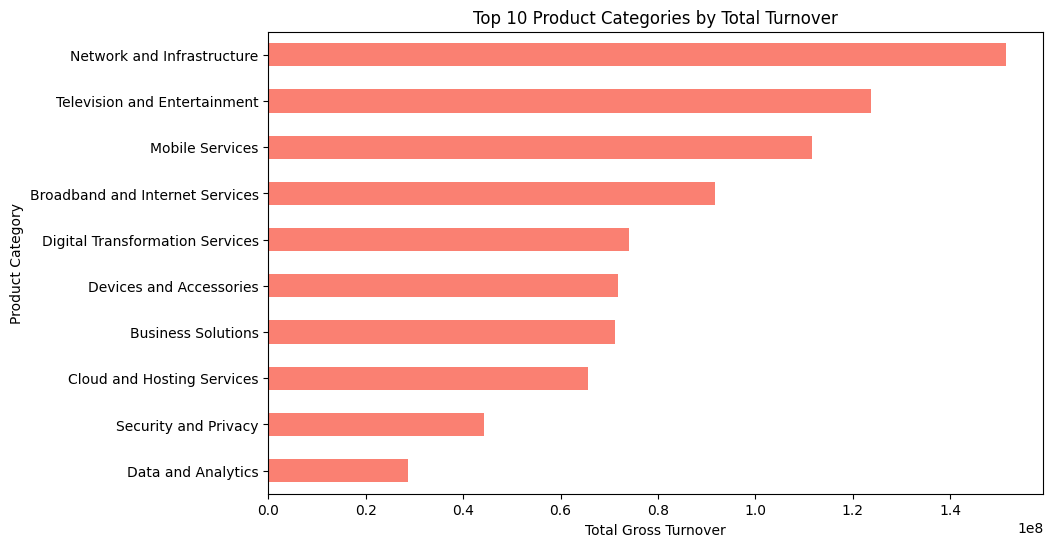

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Top 10 Product Categories by Turnover
top_cats = df_Filtered.groupby('ProdCat1_y')['GROSS_TURNOVER'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_cats.plot(kind='barh', color='salmon')
plt.title('Top 10 Product Categories by Total Turnover')
plt.xlabel('Total Gross Turnover')
plt.ylabel('Product Category')
plt.gca().invert_yaxis()
plt.show()

### Alternative Distribution Analysis
Since the turnover data has a very high variance (some small sales and some very large ones), we can use a boxplot and numerical percentiles to see the spread more clearly.

Turnover Percentiles:
0.25     116.01
0.50     296.58
0.75     823.38
0.90    2113.09
0.95    3908.11
0.99   14084.24
Name: GROSS_TURNOVER, dtype: float64


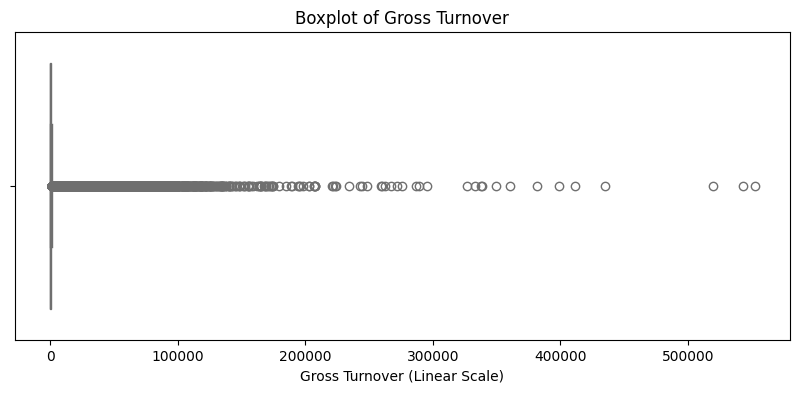

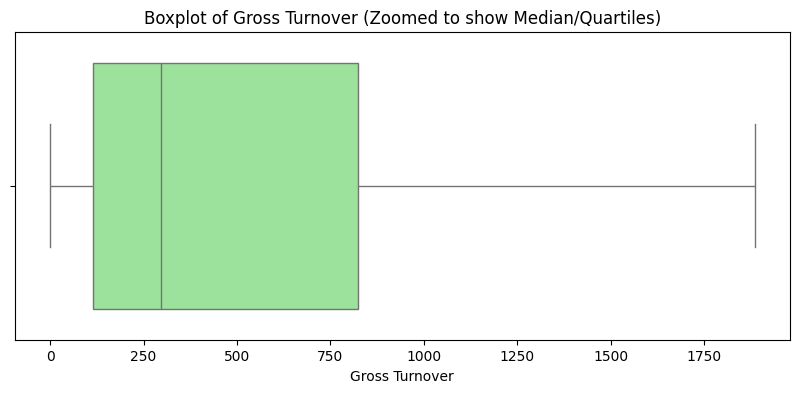

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Numerical Distribution (Percentiles)
print("Turnover Percentiles:")
print(df_Filtered['GROSS_TURNOVER'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# 2. Boxplot to visualize outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_Filtered['GROSS_TURNOVER'], color='skyblue')
plt.title('Boxplot of Gross Turnover')
plt.xlabel('Gross Turnover (Linear Scale)')
plt.show()

# 3. Zoomed in Boxplot (removing extreme outliers for visibility)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_Filtered['GROSS_TURNOVER'], showfliers=False, color='lightgreen')
plt.title('Boxplot of Gross Turnover (Zoomed to show Median/Quartiles)')
plt.xlabel('Gross Turnover')
plt.show()

## Pareto Analysis

**Pareto Analysis** is a strategic decision-making tool used to prioritize actions based on the principle that a small number of causes typically lead to a large portion of the effects. Known as the 80/20 rule or the Pareto Principle, this concept is highly applicable in customer and product management, helping businesses focus on the most impactful areas to maximize efficiency and profitability.

## Key Concepts


**i) Pareto Principle (80/20 Rule):**

In the context of customers and products, this principle suggests that roughly 80% of a company’s revenue comes from 20% of its customers or products. Understanding this can help businesses focus their efforts on the most valuable segments.

**ii) Pareto Chart:**

A Pareto chart is a graphical tool that helps visualize and prioritize the most significant factors among a set. It combines a bar graph and a line graph, where bars represent individual values in descending order, and the line shows the cumulative total.

***An example of Pareto Chart and Pareto Analysis:***

![image-2.png](attachment:image-2.png)

Here is the Pareto chart for products and their corresponding revenues. The chart consists of two key elements:

**Bar Chart:** The blue bars represent the individual revenue contributions of each product, sorted in descending order.

**Line Chart:** The red line shows the cumulative percentage of the total revenue contributed by the products. The horizontal
gray dashed line indicates the 80% mark.

***Analysis***

- Product Contribution: The first few products (A, B, and C) generate a significant portion of the revenue, highlighting the "vital few" that follow the Pareto Principle.
- Cumulative Percentage: By the time we include Product E, the cumulative revenue reaches around 80% of the total, illustrating that a small number of products contribute to the majority of the revenue.

***Implications***

- Focus on Key Products: Efforts should be concentrated on optimizing and promoting these top-performing products to maximize revenue.
- Resource Allocation: Inventory, marketing, and development resources should be prioritized for these high-impact products to enhance business efficiency and profitability.
- Customer Strategies: Understanding which products are most valued by customers can help in tailoring marketing and customer engagement strategies.


Using Pareto analysis helps businesses identify and focus on the most impactful products, ensuring efficient use of resources and targeted efforts towards driving revenue growth.

To execute the pareto analysis, you must create the required dataset. There are two levels of Product category in this dataset, use ProdCat2 for this analysis.

***Task 2.2: Create a new dataframe df_Pareto with the columns: ProdCat2, Gross_Turnover, Cumulative_GT, Cumulative_GT%***

*Hint: Cumulative_GT is Cumulative Gross Turnover which you can get by doing a cumulative sum on the Gross Turnover.*



In [35]:
# Aggregate turnover by product category
df_Pareto = df_Filtered.groupby('ProdCat2_y')['GROSS_TURNOVER'].sum().reset_index()

# Sort descending
df_Pareto = df_Pareto.sort_values(by='GROSS_TURNOVER', ascending=False)

df_Pareto.head()

,ProdCat2_y,GROSS_TURNOVER
121,Mobile Plans (Postpaid),56125893.61
132,Network Infrastructure Services,40887789.80
18,Broadband Internet (Fiber),40535399.72
122,Mobile Plans (Prepaid),31599641.39
212,Wholesale Telecom Services,25938239.22


In [36]:
# Cumulative turnover
df_Pareto['Cumulative_GT'] = df_Pareto['GROSS_TURNOVER'].cumsum()

# Cumulative percentage
total_gt = df_Pareto['GROSS_TURNOVER'].sum()

df_Pareto['Cumulative_GT%'] = (
    df_Pareto['Cumulative_GT'] / total_gt
) * 100

# Preview
df_Pareto.head()

,ProdCat2_y,GROSS_TURNOVER,Cumulative_GT,Cumulative_GT%
121,Mobile Plans (Postpaid),56125893.61,56125893.61,6.03
132,Network Infrastructure Services,40887789.80,97013683.41,10.42
18,Broadband Internet (Fiber),40535399.72,137549083.13,14.77
122,Mobile Plans (Prepaid),31599641.39,169148724.52,18.16
212,Wholesale Telecom Services,25938239.22,195086963.74,20.95


***Task 2.3: Arrive at a "Pareto filtered" dataset df_Pareto_80 with the top product categories that contribute to 80% of the Gross Turnover***

*Hint: There are 64 products that contribute to 80% of Gross Revenue turnover*

In [37]:
# Filter top 80%
df_Pareto_80 = df_Pareto[df_Pareto['Cumulative_GT%'] <= 80]

print(df_Pareto_80.shape)
df_Pareto_80.head()

(64, 4)


,ProdCat2_y,GROSS_TURNOVER,Cumulative_GT,Cumulative_GT%
121,Mobile Plans (Postpaid),56125893.61,56125893.61,6.03
132,Network Infrastructure Services,40887789.80,97013683.41,10.42
18,Broadband Internet (Fiber),40535399.72,137549083.13,14.77
122,Mobile Plans (Prepaid),31599641.39,169148724.52,18.16
212,Wholesale Telecom Services,25938239.22,195086963.74,20.95


### Detailed Pareto Analysis (Top 70 Categories)
This chart expands the view to show where the cumulative turnover actually hits the 80% threshold.

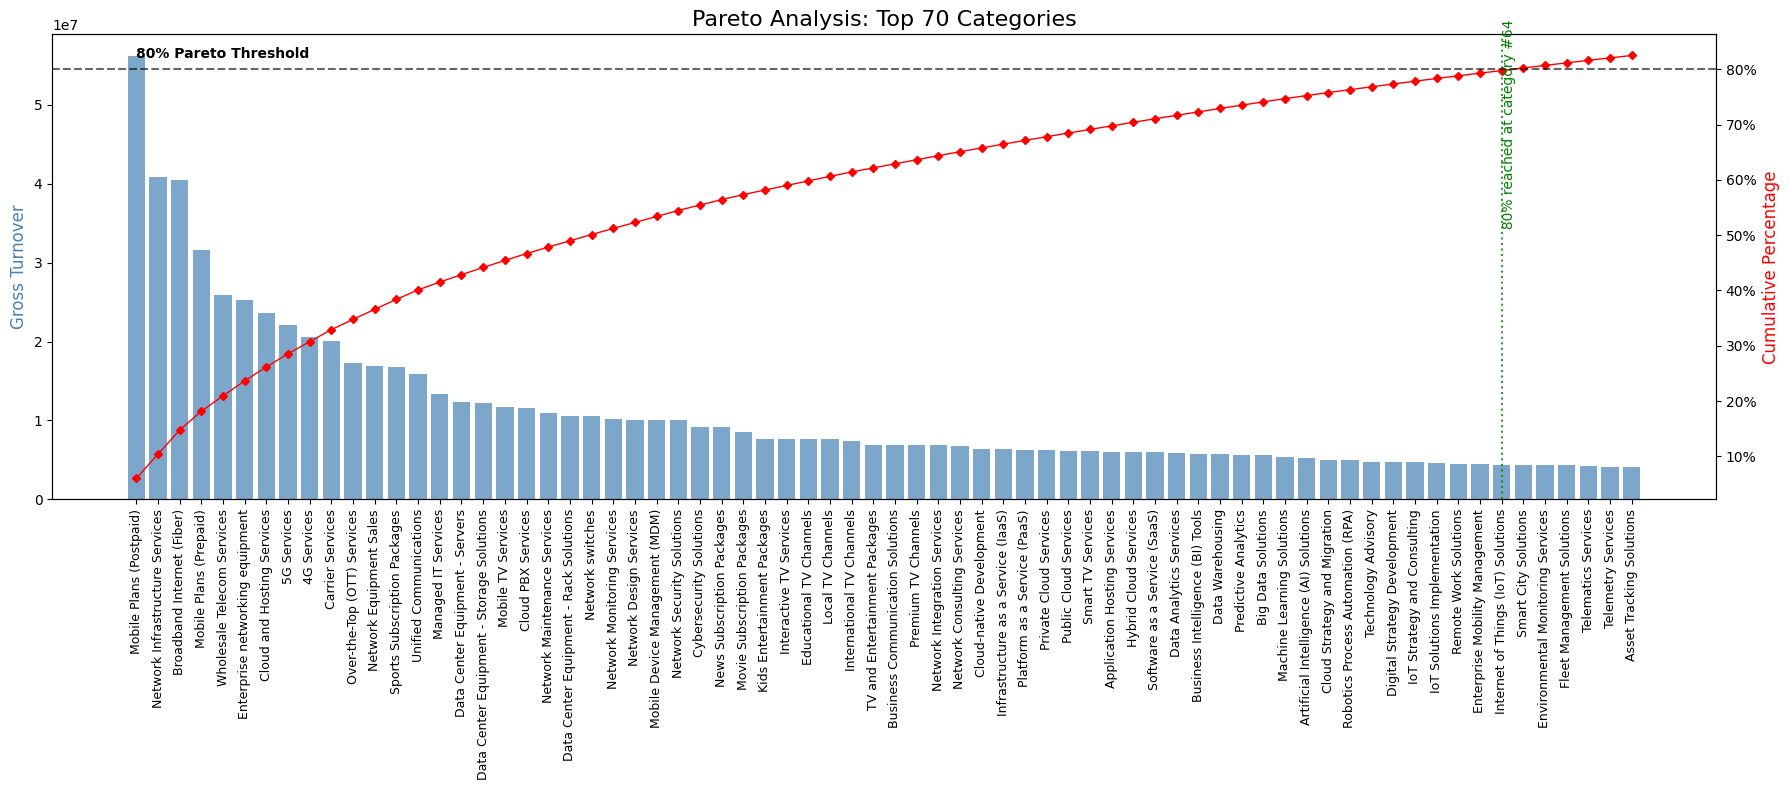

In [38]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# We plot more categories (Top 70) to ensure we cross the 80% line
top_n = 70
df_plot = df_Pareto.head(top_n)

fig, ax = plt.subplots(figsize=(18, 8))

# 1. Plot Bars
ax.bar(df_plot['ProdCat2_y'], df_plot['GROSS_TURNOVER'], color="steelblue", alpha=0.7)
ax.set_ylabel("Gross Turnover", color="steelblue", fontsize=12)

# 2. Plot Cumulative Line
ax2 = ax.twinx()
ax2.plot(df_plot['ProdCat2_y'], df_plot['Cumulative_GT%'], color="red", marker="D", ms=4, linewidth=1)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel("Cumulative Percentage", color="red", fontsize=12)

# 3. Add 80% Threshold Line
ax2.axhline(80, color="black", linestyle="--", alpha=0.6)
ax2.text(0, 82, '80% Pareto Threshold', color='black', fontweight='bold')

# Find the category where it hits 80% for a vertical marker
pareto_cutoff_idx = len(df_Pareto_80) - 1
if pareto_cutoff_idx < top_n:
    ax2.axvline(pareto_cutoff_idx, color="green", linestyle=":", alpha=0.8)
    ax2.text(pareto_cutoff_idx, 50, f'  80% reached at category #{pareto_cutoff_idx+1}', color='green', rotation=90)

plt.title(f'Pareto Analysis: Top {top_n} Categories', fontsize=16)
ax.set_xticklabels(df_plot['ProdCat2_y'], rotation=90, fontsize=9)
plt.tight_layout()
plt.show()

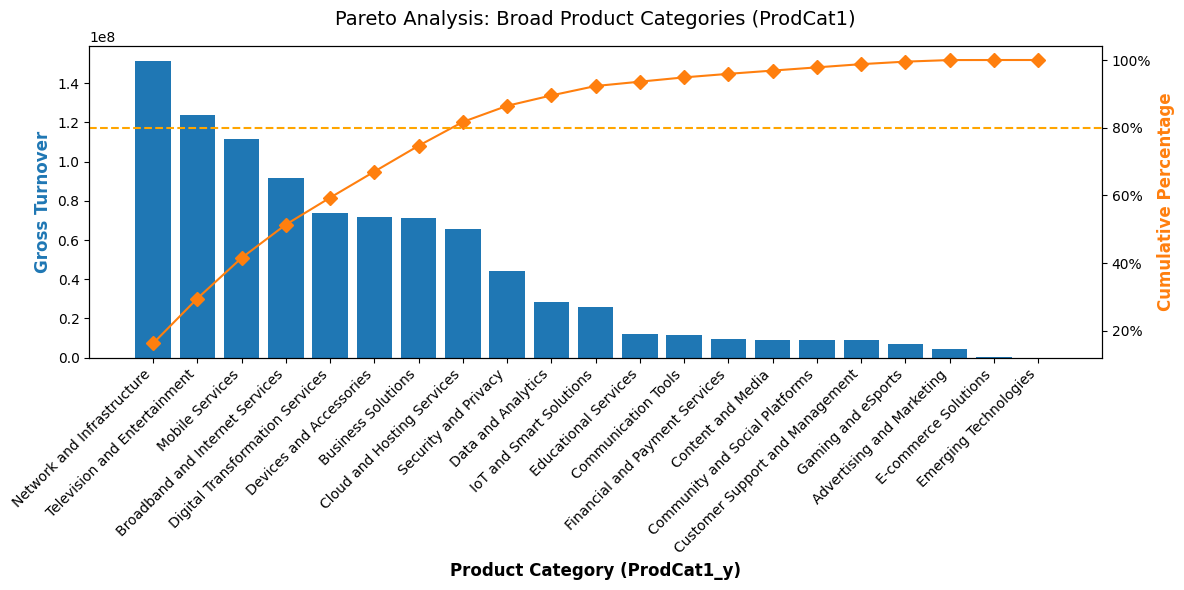

In [39]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 1. Aggregate and Sort
df_pareto_cat1 = df_Filtered.groupby('ProdCat1_y')['GROSS_TURNOVER'].sum().sort_values(ascending=False).reset_index()

# 2. Calculate Cumulative metrics
df_pareto_cat1['CumSum'] = df_pareto_cat1['GROSS_TURNOVER'].cumsum()
df_pareto_cat1['CumPerc'] = (df_pareto_cat1['CumSum'] / df_pareto_cat1['GROSS_TURNOVER'].sum()) * 100

# 3. Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_pareto_cat1['ProdCat1_y'], df_pareto_cat1['GROSS_TURNOVER'], color="C0")

# Primary Axis Titles
ax.set_xlabel('Product Category (ProdCat1_y)', fontsize=12, fontweight='bold')
ax.set_ylabel('Gross Turnover', fontsize=12, fontweight='bold', color="C0")

# Secondary Axis
ax2 = ax.twinx()
ax2.plot(df_pareto_cat1['ProdCat1_y'], df_pareto_cat1['CumPerc'], color="C1", marker="D", ms=7)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('Cumulative Percentage', fontsize=12, fontweight='bold', color="C1")

# 80% line
ax2.axhline(80, color="orange", linestyle="--")

ax.set_xticklabels(df_pareto_cat1['ProdCat1_y'], rotation=45, ha='right')
plt.title('Pareto Analysis: Broad Product Categories (ProdCat1)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

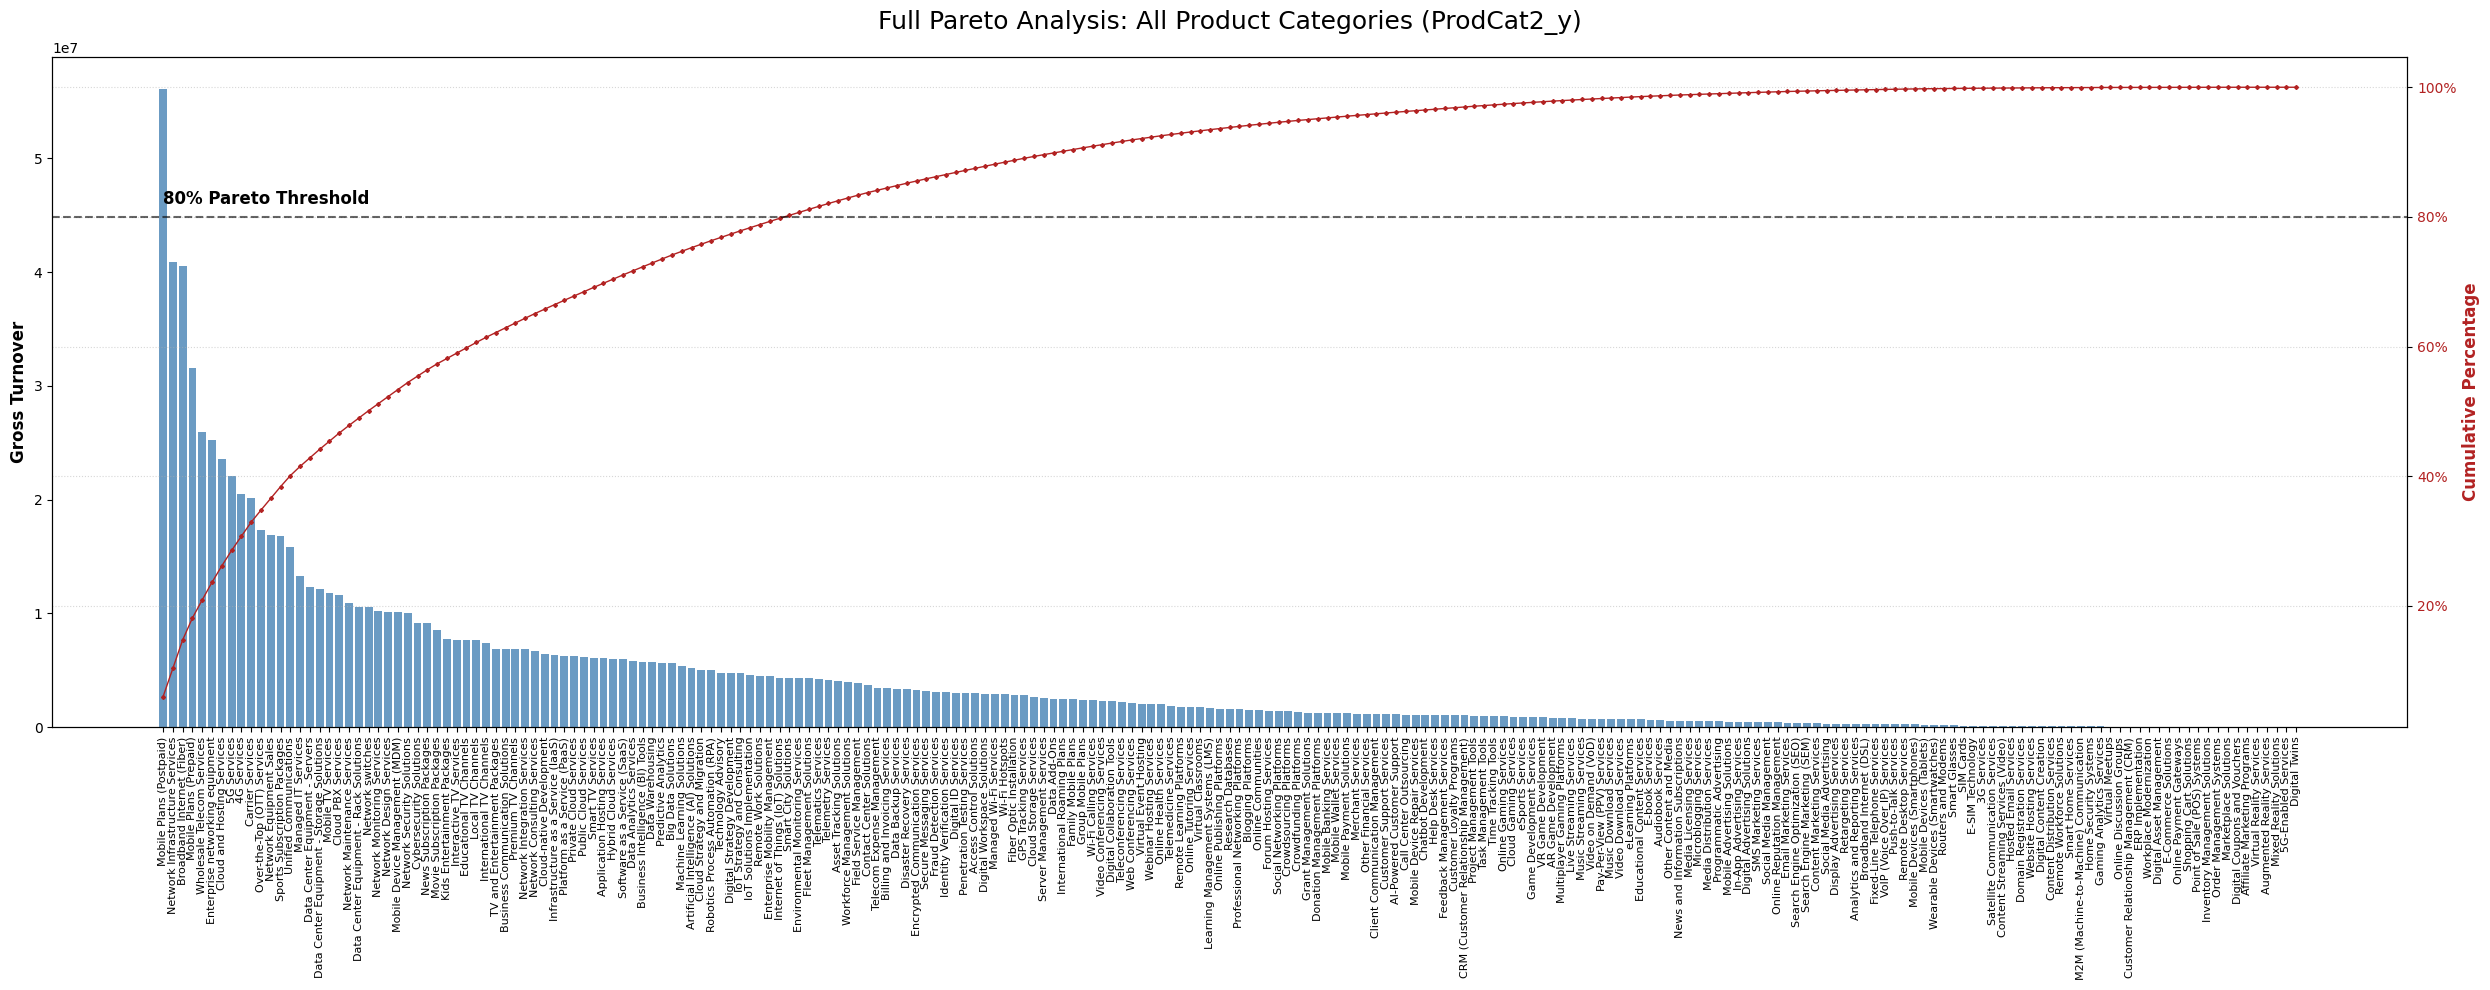

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 1. Prepare data (ensure it's sorted by Turnover)
df_pareto_full = df_Filtered.groupby('ProdCat2_y')['GROSS_TURNOVER'].sum().sort_values(ascending=False).reset_index()
df_pareto_full['Cumulative_Perc'] = (df_pareto_full['GROSS_TURNOVER'].cumsum() / df_pareto_full['GROSS_TURNOVER'].sum()) * 100

# 2. Plotting (Displaying all categories)
# We increase the figure width significantly to accommodate all labels
fig, ax = plt.subplots(figsize=(25, 10))

# Bar Chart (Turnover)
ax.bar(df_pareto_full['ProdCat2_y'], df_pareto_full['GROSS_TURNOVER'], color="steelblue", alpha=0.8)
ax.set_ylabel("Gross Turnover", fontsize=12, fontweight='bold')
ax.tick_params(axis='y')

# Line Chart (Cumulative %)
ax2 = ax.twinx()
ax2.plot(df_pareto_full['ProdCat2_y'], df_pareto_full['Cumulative_Perc'], color="firebrick", marker="D", ms=2, linewidth=1)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel("Cumulative Percentage", fontsize=12, fontweight='bold', color="firebrick")
ax2.tick_params(axis='y', labelcolor="firebrick")

# 80% Cut-off line
ax2.axhline(80, color="black", linestyle="--", alpha=0.6)
ax2.text(0, 82, '80% Pareto Threshold', color='black', fontsize=12, fontweight='bold')

plt.title('Full Pareto Analysis: All Product Categories (ProdCat2_y)', fontsize=18, pad=20)
ax.set_xticklabels(df_pareto_full['ProdCat2_y'], rotation=90, fontsize=8)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

***Task 2.3: Display the Pareto Chart***

*Hint: Your Pareto Chart will look something like this*

![image.png](attachment:image.png)


***Task 2.4: Perform the necessary action to map the top products from Pareto Analysis to the previously created master dataframe df_Filtered and store this in a new dataframe df_Filtered_Pareto.***

*Hint: Think Joins?*

### Optional: Pareto Analysis for ProdCat1 (Broad Categories)
Let's see if the 80/20 rule applies differently at the highest category level.

In [41]:
# Example redundant columns removal
cols_to_drop = ['SKU_flag', 'Invoice_flag']

for col in cols_to_drop:
    if col in df_Filtered.columns:
        df_Filtered.drop(columns=col, inplace=True)

# Rename repetitive columns
df_Filtered.rename(columns={
    'Gross_Turnover': 'GrossTurnover'
}, inplace=True)

print(df_Filtered.columns)

Index(['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE',
       'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name',
       'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line',
       'GROSS_TURNOVER', 'AMOUNT', 'CUSTOMER_NAME', 'ACCOUNT_GROUP_TXT',
       'CVR_Company_status', 'Main_account_ID_x', 'Customer_type_x',
       'ProductID_x', 'ProductCategoryID_x', 'ProdCat2_x', 'ProdCat1_x',
       'Main_account_ID_y', 'Customer_type_y', 'ProductID_y',
       'ProductCategoryID_y', 'ProdCat2_y', 'ProdCat1_y'],
      dtype='object')


In [42]:
# Map Pareto top products back to filtered master dataset

df_Filtered_Pareto = pd.merge(
    df_Filtered,
    df_Pareto_80[['ProdCat2_y']],
    on='ProdCat2_y',
    how='inner'
)

# Check output
print(df_Filtered_Pareto.shape)

df_Filtered_Pareto.head()

(644957, 27)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,ProductID_x,ProductCategoryID_x,ProdCat2_x,ProdCat1_x,Main_account_ID_y,Customer_type_y,ProductID_y,ProductCategoryID_y,ProdCat2_y,ProdCat1_y
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,4441429746,686.00,Predictive Analytics,Data and Analytics,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics
2,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,31592006,756.00,Mobile TV Services,Television and Entertainment,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment
3,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,JSF 505,809.00,4G Services,Broadband and Internet Services,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services
4,48316,123063686,30,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 406,ZLAG,...,JSF 406,809.00,4G Services,Broadband and Internet Services,103350,A-B,JSF 406,809.00,4G Services,Broadband and Internet Services


In the above dataset, you will notice that there are some columns that are repititive and redundant.

***Task 2.5: Remove the redundant columns and give a meaningful name to the repititive columns***

In [43]:
# Task 2.5: Clean up redundant columns and rename for clarity
# Ensure the dataframe exists before operating on it
if 'df_Filtered_Pareto' in locals():
    # Columns to drop (redundant _x suffixes)
    cols_to_drop_explicit = [
        'Main_account_ID_x', 'Customer_type_x', 'ProductID_x',
        'ProductCategoryID_x', 'ProdCat2_x', 'ProdCat1_x'
    ]

    # Filter for columns that actually exist in the DataFrame
    existing_cols_to_drop = [col for col in cols_to_drop_explicit if col in df_Filtered_Pareto.columns]
    df_Filtered_Pareto.drop(columns=existing_cols_to_drop, errors='ignore', inplace=True)

    # Rename _y columns to their base name for clarity, assuming they are the desired final versions
    # And rename GROSS_TURNOVER to GrossTurnover
    rename_map = {
        'Main_account_ID_y': 'Main_account_ID',
        'Customer_type_y': 'Customer_type',
        'ProductID_y': 'ProductID',
        'ProductCategoryID_y': 'ProductCategoryID',
        'ProdCat2_y': 'ProdCat2',
        'ProdCat1_y': 'ProdCat1',
        'GROSS_TURNOVER': 'GrossTurnover'
    }

    # Apply renames only if the column exists in df_Filtered_Pareto
    df_Filtered_Pareto.rename(columns={k: v for k, v in rename_map.items() if k in df_Filtered_Pareto.columns}, inplace=True)

    print("Columns after cleanup:")
    print(df_Filtered_Pareto.columns)
else:
    print("Error: df_Filtered_Pareto not found. Please run cell 7be803af first.")

Columns after cleanup:
Index(['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE',
       'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name',
       'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line',
       'GrossTurnover', 'AMOUNT', 'CUSTOMER_NAME', 'ACCOUNT_GROUP_TXT',
       'CVR_Company_status', 'Main_account_ID', 'Customer_type', 'ProductID',
       'ProductCategoryID', 'ProdCat2', 'ProdCat1'],
      dtype='object')


**This analysis gives an understanding of the top product portfolio of the company. This will be further used to perform customer segmentation.**

### 3. Customer Segmentation

The next part in this analysis is to find meaningful customer segments from the product purchase behaviour.

You will use **KMeans Clustering Algorithm** for this.

### KMeans Algorithm
The KMeans algorithm is a popular clustering technique used to partition a dataset into K clusters, where each data point belongs to the cluster with the nearest mean. Here are the steps involved in the KMeans algorithm:

**Initialization:**

- Choose the optimal number of clusters K, say 3 in this case.
- Randomly select K data points from the dataset as the initial centroids (cluster centers).

![image-2.png](attachment:image-2.png)

**Assignment Step:**

- Assign each data point to the nearest centroid. This is usually done by calculating the Euclidean distance between each data point and the centroids.
- Each data point is assigned to the cluster whose centroid is closest to it.

**Update Step:**

- Recalculate the centroids as the mean of all data points assigned to each cluster.
- The new centroid for each cluster is the average of the positions of all the data points in that cluster.

![image-3.png](attachment:image-3.png)

**Repeat:**

- Repeat the Assignment and Update steps until the centroids no longer change significantly or a specified number of iterations is reached.
- This convergence indicates that the clusters are stable, and the algorithm has found the optimal clustering.

![image-4.png](attachment:image-4.png)

**Termination:**

- The algorithm terminates when the centroids have stabilized (i.e., they do not change significantly between iterations) or after a pre-defined number of iterations.



To execute this analysis, **Main Account** and **ProdCat1** (is a broader product category and is at the highest level in the product hierarchy) data will be used.

*Note: ProdCat2 level data is at a very granular level and performing clustering analysis on this might not give meaningful clusters.*

To proceed with the customer segmentation analysis, you need to menaingfully prepare the data.

***Task 3.1: Transform the data to feed to the clustering algorithm***

- Create a copy of the above dataframe and save it as **df_segment**
- Create a Primary Key: Concatenate the Main Account (ID) and Main Account Name
- Execute a groupby operation to calculate the annual turnover of each customer for each product (ProdCat1)
- Calculate the % spend by each customer across different product categories

The resultant dataframe will have the following columns:
- Primary Key
- ProdCat1
- Gross_Turnover
- Customer Spend %

In [44]:
import pandas as pd

# Create copy
df_segment = df_Filtered_Pareto.copy()

# Create Primary Key
df_segment['Primary_Key'] = (
    df_segment['Main_account'].astype(str) + '_' +
    df_segment['Main_account_name'].astype(str)
)

# Groupby annual turnover
df_segment_group = df_segment.groupby(
    ['Primary_Key', 'ProdCat1']
)['GrossTurnover'].sum().reset_index()

# Calculate total customer spend
total_spend = df_segment_group.groupby(
    'Primary_Key'
)['GrossTurnover'].sum().reset_index()

total_spend.rename(columns={
    'GrossTurnover': 'Total_GT'
}, inplace=True)

# Merge total spend
df_segment_group = pd.merge(
    df_segment_group,
    total_spend,
    on='Primary_Key',
    how='left'
)

# Calculate spend %
df_segment_group['Customer Spend %'] = (
    df_segment_group['GrossTurnover'] /
    df_segment_group['Total_GT']
) * 100

# Final dataframe
df_segment = df_segment_group[[
    'Primary_Key',
    'ProdCat1',
    'GrossTurnover',
    'Customer Spend %'
]]

df_segment.head()

,Primary_Key,ProdCat1,GrossTurnover,Customer Spend %
0,100015_Customer Group_2149,Broadband and Internet Services,9250.04,44.25
1,100015_Customer Group_2149,Cloud and Hosting Services,124.69,0.60
2,100015_Customer Group_2149,Devices and Accessories,132.17,0.63
3,100015_Customer Group_2149,Digital Transformation Services,4106.33,19.65
4,100015_Customer Group_2149,Mobile Services,123.71,0.59


***Task 3.2: Pivot the dataset to create a matrix view of spend % of all customers on all products (ProdCat1). Save the dataframe as df_pivot. Create another dataframe df_clustering removing the primary key from the df_pivot dataframe.***

In [45]:
df_pivot = df_segment.pivot_table(
    index='Primary_Key',
    columns='ProdCat1',
    values='Customer Spend %',
    fill_value=0
).reset_index()

# Remove primary key for clustering
df_clustering = df_pivot.drop(columns=['Primary_Key'])

print(df_pivot.shape)
print(df_clustering.shape)

df_pivot.head()

(3929, 12)
(3929, 11)


ProdCat1,Primary_Key,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
0,100015_Customer Group_2149,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44
1,100022_Customer Group_1631,0.00,18.88,6.79,0.00,12.55,0.00,0.00,5.43,10.35,44.61,1.39
2,100027_Customer Group_2392,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84
3,100040_Customer Group_2150,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59
4,100041_Customer Group_477,23.34,5.27,1.18,0.85,6.21,3.94,0.00,12.24,29.98,0.24,16.77


### The Elbow Method in KMeans Clustering

The Elbow Method is a commonly used technique to determine the optimal number of clusters (K) in KMeans clustering. It helps to balance between underfitting and overfitting by finding a point where adding more clusters doesn’t significantly improve the model performance.

![image.png](attachment:image.png)

***Explanation of the Plot***

**WCSS (Within Cluster Sum of Squares) vs. Number of Clusters:**

- The x-axis represents the number of clusters (K).
- The y-axis represents the Within-Cluster Sum of Squares (WCSS), which measures the variance within each cluster.

**Plotting WCSS for Different K Values:**

- For each value of K (from 1 to 10), the KMeans algorithm is run, and the corresponding WCSS is calculated.
- The plot shows how WCSS decreases as the number of clusters increases.

**Elbow Point:**

- The red point marked on the plot indicates the "elbow point" where the rate of decrease in WCSS slows down.
- In this example, the elbow point is at K = 3. This suggests that 3 clusters are optimal for this dataset, as adding more clusters beyond this point results in only a marginal reduction in WCSS.

**Interpretation:**

- Before the Elbow Point: Adding more clusters significantly reduces WCSS, indicating that the clusters are becoming more defined and compact.
- After the Elbow Point: The reduction in WCSS slows down, meaning that adding more clusters doesn’t significantly improve the clustering.

**Conclusion**

The Elbow Method helps to identify the optimal number of clusters by looking for the point where the WCSS starts to decrease at a slower rate, balancing model complexity and performance. In this case, the plot suggests that using 3 clusters is a good choice for the dataset.

\***Task 3.3: Run K-Means clustering algorithm and identify the optimal number of clusters using Elbow Method***

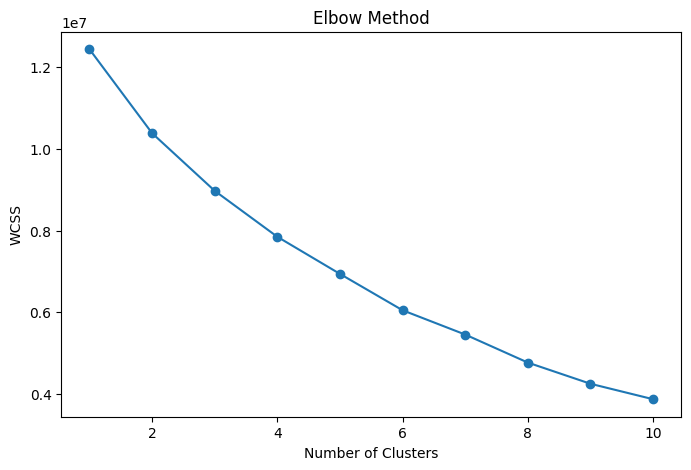

In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df_clustering)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

The Elbow Curve provides an optimal value for 'k' that is the number of clusters to be generated in the output. This value can be used as a guideline for the actual clustering run; one may vary the number of clusers in the output based on business need.



Silhouette Analysis

K=2: 0.1459
K=3: 0.1805
K=4: 0.2118
K=5: 0.2386
K=6: 0.2689
K=7: 0.2793
K=8: 0.2958
K=9: 0.3075
K=10: 0.3172
K=11: 0.3252
K=12: 0.2911
K=13: 0.2831
K=14: 0.2761


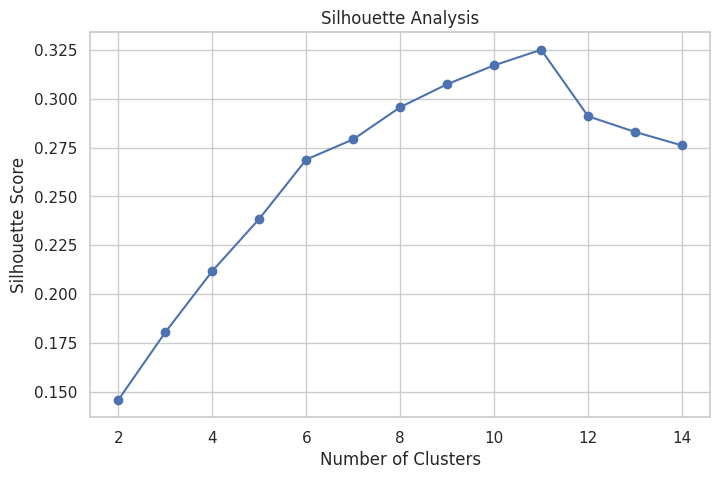

In [67]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2, 15):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_clustering)

    score = silhouette_score(
        df_clustering,
        labels
    )

    silhouette_scores.append(score)

    print(f"K={k}: {score:.4f}")

plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.show()

K=2: 1.5555
K=3: 1.4722
K=4: 1.4399
K=5: 1.5768
K=6: 1.2750
K=7: 1.2536
K=8: 1.1768
K=9: 1.1122
K=10: 1.0590


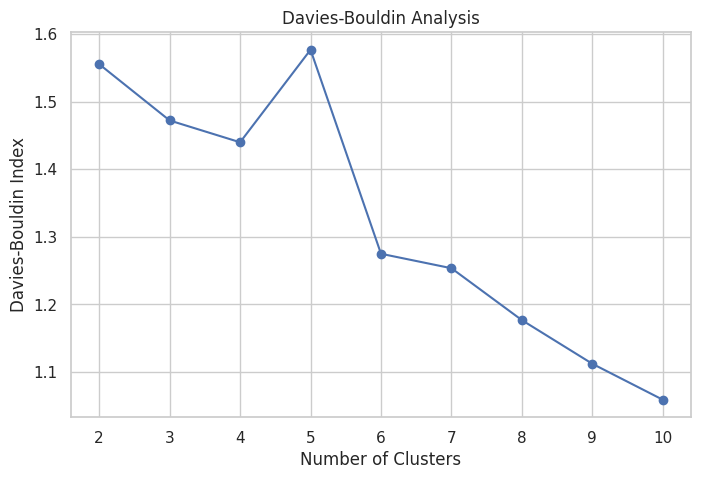

In [68]:
# Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_clustering)

    score = davies_bouldin_score(
        df_clustering,
        labels
    )

    db_scores.append(score)

    print(f"K={k}: {score:.4f}")

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    db_scores,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Analysis')

plt.show()

In [69]:
#comparing the K

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,16):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_clustering)

    score = silhouette_score(
        df_clustering,
        labels
    )

    scores.append(score)

    print(f"K={k}: {score:.4f}")

K=2: 0.1459
K=3: 0.1805
K=4: 0.2118
K=5: 0.2386
K=6: 0.2689
K=7: 0.2793
K=8: 0.2958
K=9: 0.3075
K=10: 0.3172
K=11: 0.3252
K=12: 0.2911
K=13: 0.2831
K=14: 0.2761
K=15: 0.2850


The Elbow Method suggested an optimal cluster size around K=3, indicating diminishing returns after 3 clusters. However, the Silhouette Score achieved its highest value at K=11, suggesting stronger separation between clusters. Since the dataset provided for the analysis was structured around 11 clusters and higher segmentation granularity was preferred for deeper customer/product categorization, K=11 was selected for the final model.

***Task 3.4: Run the KMeans algorithm with optimal number of clusters***

In [70]:
# Run KMeans
kmeans = KMeans(
    n_clusters=11,
    random_state=42,
    n_init=10
)

# Fit model
kmeans.fit(df_clustering)

# Create cluster labels
df_pivot['Cluster'] = kmeans.labels_

df_pivot.head()

ProdCat1,Primary_Key,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment,Cluster
0,100015_Customer Group_2149,9250.04,0.00,124.69,0.00,132.17,4106.33,0.00,123.71,4982.87,0.00,2182.68,8
1,100022_Customer Group_1631,0.00,3266.52,1175.17,0.00,2172.44,0.00,0.00,939.44,1791.34,7720.43,239.82,5
2,100027_Customer Group_2392,15516.84,0.00,467.41,644.18,0.00,0.00,0.00,16175.12,2098.05,0.00,10331.28,8
3,100040_Customer Group_2150,0.00,1635.70,1391.13,0.00,0.00,0.00,0.00,212.97,28966.00,0.00,190.15,1
4,100041_Customer Group_477,47004.97,10610.25,2367.25,1711.53,12502.09,7931.77,0.00,24659.26,60383.23,476.74,33786.61,6


In [71]:
#checking for cluster size
df_pivot['Cluster'].value_counts().sort_index()

,count
Cluster,
0,359
1,606
2,203
3,397
4,264
5,189
6,1179
7,127
8,223


***Task 3.5: From the above clusters, create cluster profile***

***Task 3.5.1: Map each customers to their respective cluster in df_segment dataset***

In [72]:
# Merge cluster labels
df_segment = pd.merge(
    df_segment,
    df_pivot[['Primary_Key', 'Cluster']],
    on='Primary_Key',
    how='left'
)

df_segment.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Primary_Key,Cluster
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,Debtors,Active,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,103350_Customer Group_24,6
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,Debtors,Active,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,103350_Customer Group_24,6
2,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,Debtors,Active,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,103350_Customer Group_24,6
3,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,Debtors,Active,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,103350_Customer Group_24,6
4,48316,123063686,30,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 406,ZLAG,...,Debtors,Active,103350,A-B,JSF 406,809.00,4G Services,Broadband and Internet Services,103350_Customer Group_24,6


***Task 3.5.2: Create a cluster profile table with the cluster label, Gross Turnover for each cluster, Number of unique customers in each cluster, % share of Gross Turnover of each cluster for each product.***

*Illustrative: Here is a snapshot of the desired cluster profile:*
![image-2.png](attachment:image-2.png)

In [73]:
import pandas as pd

# Ensure 'Cluster' is mapped to df_segment before profiling
if 'Cluster' not in df_segment.columns:
    df_segment = pd.merge(
        df_segment,
        df_pivot[['Primary_Key', 'Cluster']],
        on='Primary_Key',
        how='left'
    )

# 1. Calculate cluster-level aggregates
cluster_profile = df_segment.groupby('Cluster').agg({
    'GrossTurnover': 'sum',
    'Primary_Key': 'nunique'
}).reset_index()

cluster_profile.rename(columns={
    'GrossTurnover': 'Cluster_GrossTurnover',
    'Primary_Key': 'Unique_Customers'
}, inplace=True)

# 2. Calculate the % share of Gross Turnover of each cluster for each ProdCat1
cat_share = df_segment.groupby(['Cluster', 'ProdCat1'])['GrossTurnover'].sum().reset_index()

# Merge with cluster totals to calculate percentage
cat_share = pd.merge(cat_share, cluster_profile[['Cluster', 'Cluster_GrossTurnover']], on='Cluster')
cat_share['Share_%'] = (cat_share['GrossTurnover'] / cat_share['Cluster_GrossTurnover']) * 100

# Pivot to get the desired matrix view
cat_share_pivot = cat_share.pivot(index='Cluster', columns='ProdCat1', values='Share_%').reset_index().fillna(0)

# 3. Final Merge
cluster_profile = pd.merge(cluster_profile, cat_share_pivot, on='Cluster')

# Calculate overall GT Share
cluster_profile['GT_Overall_Share_%'] = (cluster_profile['Cluster_GrossTurnover'] / cluster_profile['Cluster_GrossTurnover'].sum()) * 100

display(cluster_profile)

,Cluster,Cluster_GrossTurnover,Unique_Customers,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment,GT_Overall_Share_%
0,0,56373215.23,359,4.19,4.02,2.25,0.92,9.32,2.48,0.13,64.49,4.05,0.59,7.55,7.59
1,1,39606093.93,606,1.62,1.35,5.53,2.30,3.17,3.83,0.03,7.66,66.23,1.88,6.40,5.33
2,2,43396611.31,203,8.52,2.38,4.02,1.61,44.87,12.24,0.07,11.50,3.36,0.25,11.16,5.84
3,3,25357543.71,397,4.29,1.83,6.51,2.36,4.74,5.06,0.00,4.69,8.43,2.42,59.67,3.41
4,4,10727321.75,264,4.43,1.36,55.25,1.30,2.27,4.64,0.06,3.89,9.80,1.15,15.85,1.44
5,5,3428954.53,189,0.17,2.54,6.75,2.75,2.63,3.41,0.00,6.28,8.40,59.27,7.80,0.46
6,6,402630240.69,1179,5.98,4.84,8.59,4.46,8.57,8.67,0.91,11.12,25.05,3.42,18.39,54.19
7,7,12614991.31,127,2.92,1.91,2.29,48.16,4.13,13.27,0.00,4.17,8.70,1.08,13.38,1.70
8,8,92646406.09,223,49.98,6.75,3.90,1.04,5.12,8.25,0.37,3.35,8.86,0.45,11.92,12.47
9,9,33939736.65,248,7.77,1.23,6.59,0.86,7.11,53.10,0.50,4.64,6.99,0.78,10.43,4.57


### 4. Prepare data for Tableau Dashboard

From here, you will be creating the visualizations in Tableau. But before, creating the required visualizations in Tableau, you should prepare the data.

Here is a reference of how data for visualizations for **Customer Segmentation** looks like:

![image-5.png](attachment:image-5.png)






Here is a reference of how data for visualizations for **Product Categorization** looks like:

![image-4.png](attachment:image-4.png)

where:

- Product ID: SKU ID
- Gross Turnover (sum), Amount (sum), Invoice_count (distinct count of invoices), Main_account_count (distinct count of main accounts): fields aggregated at SKU level
- Above columns with _percluster: fields aggregated at cluster level
- Frequency (%) : number of transactions the SKU appeared on, when compared to all transactions in a cluster
- Customer Prevalence (%) within cluster : Percentage of customers within a cluster who purchase the SKU



In [74]:
# Customer segmentation output
df_customer_segmentation = pd.merge(

    df_Filtered_Pareto,
    df_pivot[['Primary_Key', 'Cluster']],
    left_on=(
        df_Filtered_Pareto['Main_account'].astype(str)
        + '_'
        + df_Filtered_Pareto['Main_account_name'].astype(str)
    ),
    right_on='Primary_Key',
    how='left'

)

df_customer_segmentation.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Primary_Key,Cluster
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,Debtors,Active,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,103350_Customer Group_24,6
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,Debtors,Active,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,103350_Customer Group_24,6
2,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,Debtors,Active,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,103350_Customer Group_24,6
3,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,Debtors,Active,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,103350_Customer Group_24,6
4,48316,123063686,30,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 406,ZLAG,...,Debtors,Active,103350,A-B,JSF 406,809.00,4G Services,Broadband and Internet Services,103350_Customer Group_24,6


In [75]:
# SKU level aggregation
df_product = df_customer_segmentation.groupby(
    ['Cluster', 'PRODUCT']
).agg({
    'GrossTurnover': 'sum',
    'AMOUNT': 'sum',
    'INVOICE_NUMBER': 'nunique',
    'Main_account': 'nunique'
}).reset_index()

# Rename columns
df_product.rename(columns={
    'INVOICE_NUMBER': 'Invoice_count',
    'Main_account': 'Main_account_count'
}, inplace=True)

df_product.head()

,Cluster,PRODUCT,GrossTurnover,AMOUNT,Invoice_count,Main_account_count
0,0,1,30.40,1,1,1
1,0,10000853906,280.54,2,1,1
2,0,1006,18802.28,72,4,4
3,0,1007,173.54,10,1,1
4,0,1010,57.05,3,1,1


In [76]:
# Calculate Cluster-level totals for normalization
# Ensure the required dataframe exists in the current session
if 'df_customer_segmentation' not in locals():
    print("Warning: df_customer_segmentation not found. Please run the preceding cell first.")
else:
    # Using 'GrossTurnover' and 'AMOUNT' as they appear in the dataframe schema
    cluster_totals = df_customer_segmentation.groupby('Cluster').agg({
        'INVOICE_NUMBER': 'nunique',
        'Main_account': 'nunique',
        'GrossTurnover': 'sum',
        'AMOUNT': 'sum'
    }).reset_index()

    cluster_totals.rename(columns={
        'INVOICE_NUMBER': 'Total_Invoices_Cluster',
        'Main_account': 'Total_Customers_Cluster',
        'GrossTurnover': 'GrossTurnover_percluster',
        'AMOUNT': 'Amount_percluster'
    }, inplace=True)

    # Merge cluster totals into the product-cluster dataframe
    df_product = pd.merge(df_product, cluster_totals, on='Cluster', how='left')

    # Calculate Prevalence and Frequency %
    df_product['Frequency (%)'] = (df_product['Invoice_count'] / df_product['Total_Invoices_Cluster']) * 100
    df_product['Customer Prevalence (%) within cluster'] = (df_product['Main_account_count'] / df_product['Total_Customers_Cluster']) * 100

    display(df_product.head())

,Cluster,PRODUCT,GrossTurnover,AMOUNT,Invoice_count,Main_account_count,Total_Invoices_Cluster,Total_Customers_Cluster,GrossTurnover_percluster,Amount_percluster,Frequency (%),Customer Prevalence (%) within cluster
0,0,1,30.40,1,1,1,8874,359,56373215.23,1377460,0.01,0.28
1,0,10000853906,280.54,2,1,1,8874,359,56373215.23,1377460,0.01,0.28
2,0,1006,18802.28,72,4,4,8874,359,56373215.23,1377460,0.05,1.11
3,0,1007,173.54,10,1,1,8874,359,56373215.23,1377460,0.01,0.28
4,0,1010,57.05,3,1,1,8874,359,56373215.23,1377460,0.01,0.28


In [82]:
import pandas as pd
from sklearn.cluster import KMeans

# 1. Re-calculate df_Pareto_80 to ensure it is in memory
# Use ProdCat2_y as it exists in df_Filtered
df_Pareto = df_Filtered.groupby('ProdCat2_y')['GROSS_TURNOVER'].sum().sort_values(ascending=False).reset_index()
df_Pareto['Cumulative_GT%'] = (df_Pareto['GROSS_TURNOVER'].cumsum() / df_Pareto['GROSS_TURNOVER'].sum()) * 100
# df_Pareto_80 will also have 'ProdCat2_y'
df_Pareto_80 = df_Pareto[df_Pareto['Cumulative_GT%'] <= 80]

# 2. Create df_Filtered_Pareto by merging df_Filtered with the top Pareto product categories
# Use ProdCat2_y for merging as it's the column in df_Filtered
df_Filtered_Pareto = pd.merge(df_Filtered, df_Pareto_80[['ProdCat2_y']], on='ProdCat2_y', how='inner')

# --- Start of logic replicated from cell 27e7c51f to clean df_Filtered_Pareto ---
# Columns to drop (redundant _x suffixes)
cols_to_drop_explicit = [
    'Main_account_ID_x', 'Customer_type_x', 'ProductID_x',
    'ProductCategoryID_x', 'ProdCat2_x', 'ProdCat1_x'
]

# Filter for columns that actually exist in the DataFrame
existing_cols_to_drop = [col for col in cols_to_drop_explicit if col in df_Filtered_Pareto.columns]
df_Filtered_Pareto.drop(columns=existing_cols_to_drop, errors='ignore', inplace=True)

# Rename _y columns to their base name for clarity, assuming they are the desired final versions
# And rename GROSS_TURNOVER to GrossTurnover
rename_map = {
    'Main_account_ID_y': 'Main_account_ID',
    'Customer_type_y': 'Customer_type',
    'ProductID_y': 'ProductID',
    'ProductCategoryID_y': 'ProductCategoryID',
    'ProdCat2_y': 'ProdCat2',
    'ProdCat1_y': 'ProdCat1',
    'GROSS_TURNOVER': 'GrossTurnover'
}

# Apply renames only if the column exists in df_Filtered_Pareto
df_Filtered_Pareto.rename(columns={k: v for k, v in rename_map.items() if k in df_Filtered_Pareto.columns}, inplace=True)
# --- End of logic replicated from cell 27e7c51f ---


# 3. Re-create df_pivot and Cluster labels using the now cleaned df_Filtered_Pareto
df_segment = df_Filtered_Pareto.copy()
df_segment['Primary_Key'] = df_segment['Main_account'].astype(str) + '_' + df_segment['Main_account_name'].astype(str)

# Now use the cleaned column names: ProdCat1 and GrossTurnover
df_pivot = df_segment.pivot_table(index='Primary_Key', columns='ProdCat1', values='GrossTurnover', aggfunc='sum', fill_value=0)
df_clustering = df_pivot.apply(lambda x: (x/x.sum())*100, axis=1)

kmeans = KMeans(n_clusters=11, random_state=42, n_init=10)
df_pivot['Cluster'] = kmeans.fit_predict(df_clustering)
df_pivot = df_pivot.reset_index()

# 4. Create the segmentation base dataframe
df_customer_segmentation = pd.merge(
    df_Filtered_Pareto,
    df_pivot[['Primary_Key', 'Cluster']],
    left_on=(df_Filtered_Pareto['Main_account'].astype(str) + '_' + df_Filtered_Pareto['Main_account_name'].astype(str)),
    right_on='Primary_Key',
    how='left'
)

# 5. Aggregate at SKU level
# Now use the cleaned column names: ProductID and GrossTurnover
df_product = df_customer_segmentation.groupby(['Cluster', 'ProductID', 'PRODUCT']).agg({
    'GrossTurnover': 'sum',
    'AMOUNT': 'sum',
    'INVOICE_NUMBER': 'nunique',
    'Main_account': 'nunique'
}).reset_index()

df_product.rename(columns={'INVOICE_NUMBER': 'Invoice_count', 'Main_account': 'Main_account_count'}, inplace=True)

# 6. Calculate Cluster-level totals for normalization
# Now use the cleaned column name: GrossTurnover
cluster_totals = df_customer_segmentation.groupby('Cluster').agg({
    'INVOICE_NUMBER': 'nunique',
    'Main_account': 'nunique',
    'GrossTurnover': 'sum',
    'AMOUNT': 'sum'
}).reset_index()

cluster_totals.rename(columns={
    'INVOICE_NUMBER': 'Total_Invoices_Cluster',
    'Main_account': 'Total_Customers_Cluster',
    'GrossTurnover': 'GrossTurnover_percluster',
    'AMOUNT': 'Amount_percluster'
}, inplace=True)

# 7. Final Merge and Metrics
df_product = pd.merge(df_product, cluster_totals, on='Cluster', how='left')
df_product['Frequency (%)'] = (df_product['Invoice_count'] / df_product['Total_Invoices_Cluster']) * 100
df_product['Customer Prevalence (%) within cluster'] = (df_product['Main_account_count'] / df_product['Total_Customers_Cluster']) * 100

display(df_product.head())

,Cluster,ProductID,PRODUCT,GrossTurnover,AMOUNT,Invoice_count,Main_account_count,Total_Invoices_Cluster,Total_Customers_Cluster,GrossTurnover_percluster,Amount_percluster,Frequency (%),Customer Prevalence (%) within cluster
0,0,1,1,30.40,1,1,1,8874,359,56373215.23,1377460,0.01,0.28
1,0,10000853906,10000853906,280.54,2,1,1,8874,359,56373215.23,1377460,0.01,0.28
2,0,1006,1006,18802.28,72,4,4,8874,359,56373215.23,1377460,0.05,1.11
3,0,1007,1007,173.54,10,1,1,8874,359,56373215.23,1377460,0.01,0.28
4,0,1010,1010,57.05,3,1,1,8874,359,56373215.23,1377460,0.01,0.28


In [83]:
import pandas as pd

# 1. Finalize df_product columns for Tableau
# Correcting the column names to match the actual dataframe schema from cell 2c20cd8b
df_product_final = df_product[[
    'Cluster', 'ProductID', 'PRODUCT', 'GrossTurnover', 'AMOUNT',
    'Invoice_count', 'Main_account_count',
    'GrossTurnover_percluster', 'Amount_percluster',
    'Total_Invoices_Cluster', 'Total_Customers_Cluster',
    'Frequency (%)', 'Customer Prevalence (%) within cluster'
]].copy()

# Standardize names to match the reference requirement
df_product_final.rename(columns={
    'GrossTurnover_percluster': 'GROSS_TURNOVER_percluster',
    'Amount_percluster': 'AMOUNT_percluster',
    'Total_Invoices_Cluster': 'Invoice_count_perCluster',
    'Total_Customers_Cluster': 'Main_account_count_perCluster'
}, inplace=True)

# 2. Select relevant columns for df_customer_segmentation
df_customer_tableau = df_customer_segmentation[[
    'Cluster', 'Primary_Key', 'ProdCat1', 'ProdCat2', 'GrossTurnover', 'INVOICE_NUMBER'
]].copy()

df_customer_tableau.rename(columns={'INVOICE_NUMBER': 'Invoice_Count'}, inplace=True)

# 3. Export to CSV for Tableau
df_customer_tableau.to_csv('customer_segmentation_output.csv', index=False)
df_product_final.to_csv('product_categorization_output.csv', index=False)

print("Cleaned files exported successfully:")
print("- customer_segmentation_output.csv")
print("- product_categorization_output.csv")

display(df_product_final.head())

Cleaned files exported successfully:
- customer_segmentation_output.csv
- product_categorization_output.csv


,Cluster,ProductID,PRODUCT,GrossTurnover,AMOUNT,Invoice_count,Main_account_count,GROSS_TURNOVER_percluster,AMOUNT_percluster,Invoice_count_perCluster,Main_account_count_perCluster,Frequency (%),Customer Prevalence (%) within cluster
0,0,1,1,30.40,1,1,1,56373215.23,1377460,8874,359,0.01,0.28
1,0,10000853906,10000853906,280.54,2,1,1,56373215.23,1377460,8874,359,0.01,0.28
2,0,1006,1006,18802.28,72,4,4,56373215.23,1377460,8874,359,0.05,1.11
3,0,1007,1007,173.54,10,1,1,56373215.23,1377460,8874,359,0.01,0.28
4,0,1010,1010,57.05,3,1,1,56373215.23,1377460,8874,359,0.01,0.28


### Visualizing K-Means Clusters

To visualize the clusters, we'll first reduce the dimensionality of our data using **Principal Component Analysis (PCA)**. Since we have 11 product categories, directly plotting them is not feasible. PCA will help us project the data into a 2D space while retaining as much variance as possible, allowing for a visual representation of the clusters.

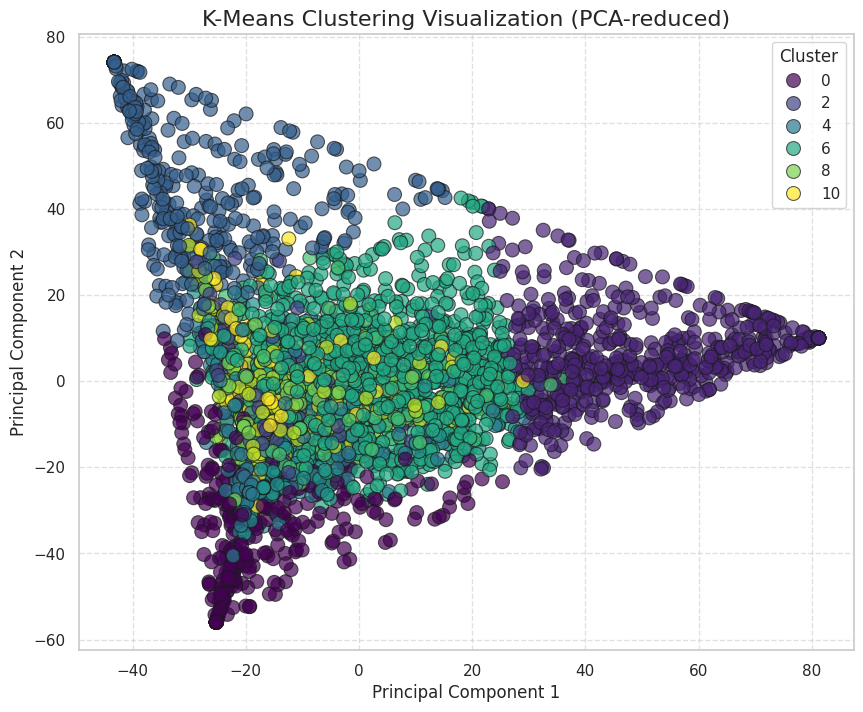

In [84]:
from sklearn.decomposition import PCA

# Initialize PCA to 2 components
pca = PCA(n_components=2)

# Fit PCA on the df_clustering data and transform it
df_pca = pca.fit_transform(df_clustering)

# Create a new DataFrame for the PCA results
df_pca = pd.DataFrame(data = df_pca, columns = ['PC1', 'PC2'])

# Add the cluster labels to the PCA DataFrame
df_pca['Cluster'] = df_pivot['Cluster']

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df_pca,
    palette='viridis',
    s=100,
    alpha=0.7,
    edgecolor='k'
)
plt.title('K-Means Clustering Visualization (PCA-reduced)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 5. Product Categorization

This section focuses on categorizing products within each customer segment based on their importance to customers and revenue contribution. This categorization will help in tailoring marketing strategies.


Cluster Profile Table (Percentage Distribution):


Product_Category,Core Products,Hyper Core Products,Long-tail Products,Specialty Products,Standard Products
Cluster,,,,,
0,0.00,0.00,97.13,2.87,0.00
1,0.01,0.00,90.76,9.23,0.00
2,0.03,0.00,93.82,6.15,0.00
3,0.00,0.00,91.19,8.81,0.00
4,0.00,0.00,89.73,10.27,0.00
5,0.04,0.00,89.22,10.74,0.00
6,0.07,0.00,88.71,11.21,0.01
7,0.03,0.00,96.01,3.94,0.03
8,0.04,0.00,95.44,4.53,0.00


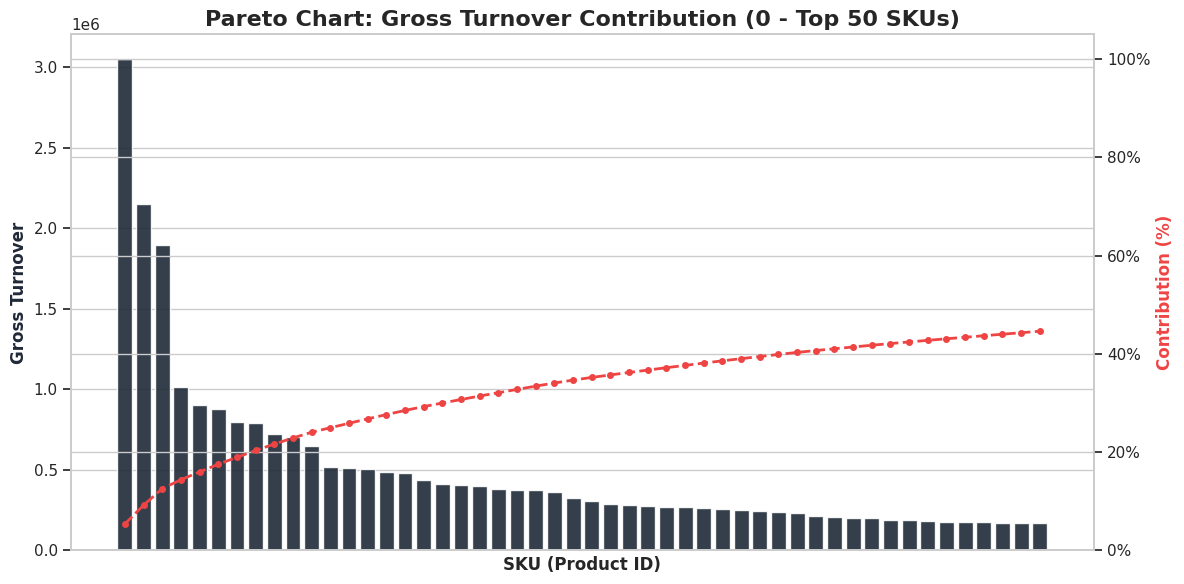

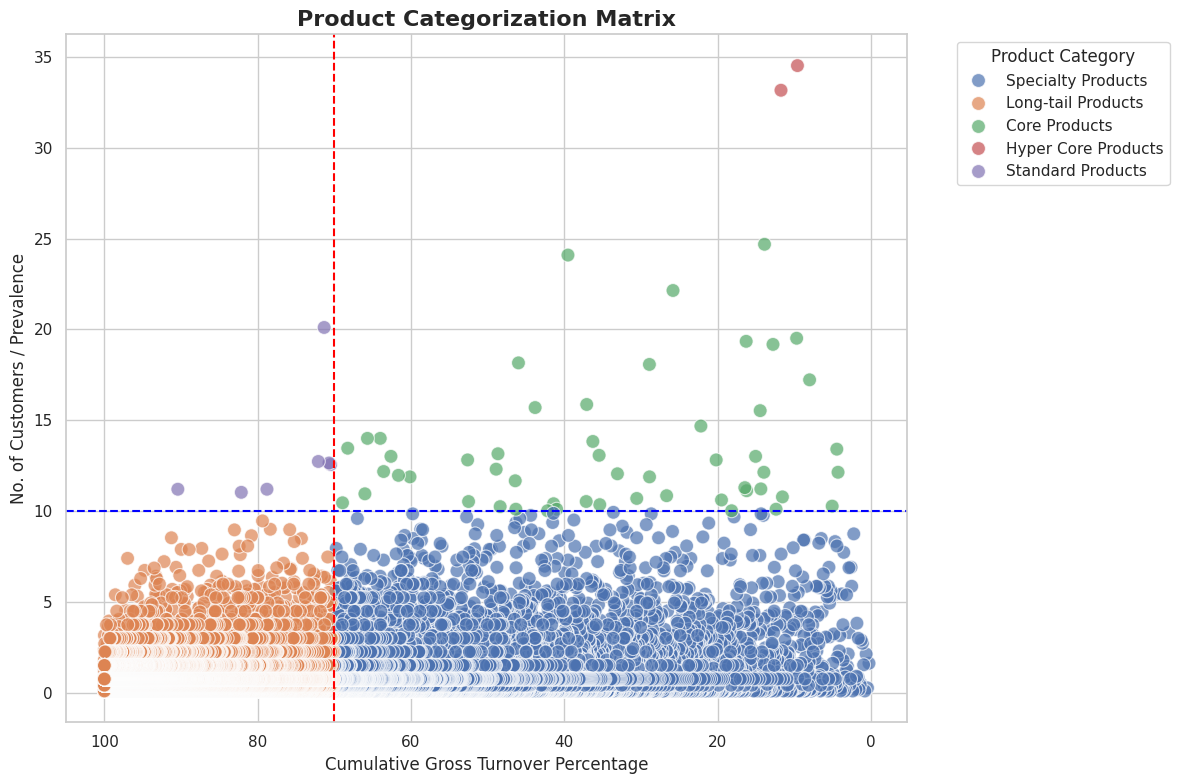

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

# ==========================================
# SECTION 1: CUMULATIVE TURNOVER CALCULATION
# ==========================================

# Sort products within each cluster by GrossTurnover in descending order
df_product_final_sorted = df_product_final.sort_values(
    by=['Cluster', 'GrossTurnover'],
    ascending=[True, False]
).copy()

# Calculate cumulative gross turnover within each cluster
df_product_final_sorted['Cumulative_GrossTurnover'] = (
    df_product_final_sorted.groupby('Cluster')['GrossTurnover'].cumsum()
)

# Calculate cumulative gross turnover percentage within each cluster
df_product_final_sorted['Cumulative_GrossTurnover_Perc'] = (
    df_product_final_sorted.groupby('Cluster')['Cumulative_GrossTurnover']
    .transform(lambda x: (x / x.max()) * 100)
)

# Update dataframe
df_product_final = df_product_final_sorted

# DROPPING EXISTING CATEGORY COLUMNS TO PREVENT MERGE ERROR
cols_to_clean = ['ProdCat1', 'ProdCat2']
for c in cols_to_clean:
    if c in df_product_final.columns:
        df_product_final = df_product_final.drop(columns=[c])

# Merge product category information
df_product_final = df_product_final.merge(
    df_ProdCategories[['ProductID', 'ProdCat1', 'ProdCat2']],
    on='ProductID',
    how='left'
)

# ==========================================
# SECTION 2: CATEGORIZATION THRESHOLDS
# ==========================================

# Hyper Core thresholds
HYPER_CORE_REVENUE = 30
HYPER_CORE_PREVALENCE = 30

# General thresholds
REVENUE_HIGH_THRESHOLD = 70
PREVALENCE_HIGH_THRESHOLD = 10

def categorize_product(row):
    revenue_perc = row['Cumulative_GrossTurnover_Perc']
    prevalence_perc = row['Customer Prevalence (%) within cluster']

    # Hyper Core Products
    if revenue_perc <= HYPER_CORE_REVENUE and prevalence_perc > HYPER_CORE_PREVALENCE:
        return 'Hyper Core Products'
    # Core Products
    elif revenue_perc <= REVENUE_HIGH_THRESHOLD and prevalence_perc > PREVALENCE_HIGH_THRESHOLD:
        return 'Core Products'
    # Specialty Products
    elif revenue_perc <= REVENUE_HIGH_THRESHOLD and prevalence_perc <= PREVALENCE_HIGH_THRESHOLD:
        return 'Specialty Products'
    # Standard Products
    elif revenue_perc > REVENUE_HIGH_THRESHOLD and prevalence_perc > PREVALENCE_HIGH_THRESHOLD:
        return 'Standard Products'
    # Long-tail Products
    else:
        return 'Long-tail Products'

# Apply categorization
df_product_final['Product_Category'] = df_product_final.apply(
    categorize_product,
    axis=1
)

# ==========================================
# SECTION 3: CLUSTER PROFILE TABLE
# ==========================================

# Analyze distribution of product categories within each cluster
product_category_distribution = (
    df_product_final
    .groupby(['Cluster', 'Product_Category'])
    .size()
    .unstack(fill_value=0)
)

# Convert to percentage distribution
product_category_distribution_perc = (
    product_category_distribution.apply(
        lambda x: x / x.sum() * 100,
        axis=1
    )
)

print("\nCluster Profile Table (Percentage Distribution):")
display(product_category_distribution_perc)

# ==========================================
# SECTION 4: VISUALIZATIONS
# ==========================================

sns.set_theme(style="whitegrid")

# --- CHART 1: PARETO CHART ---
target_cluster = df_product_final['Cluster'].unique()[0]
df_pareto = df_product_final[df_product_final['Cluster'] == target_cluster].copy()
df_pareto = df_pareto.head(50)

fig, ax1 = plt.subplots(figsize=(12, 6))
color_bar = '#1f2937'
ax1.bar(
    df_pareto['ProductID'].astype(str),
    df_pareto['GrossTurnover'],
    color=color_bar,
    alpha=0.9
)
ax1.set_xlabel('SKU (Product ID)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Gross Turnover', color=color_bar, fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=90)
if len(df_pareto) > 30:
    ax1.set_xticks([])

ax2 = ax1.twinx()
color_line = '#ef4444'
ax2.plot(
    df_pareto['ProductID'].astype(str),
    df_pareto['Cumulative_GrossTurnover_Perc'],
    color=color_line,
    marker='o',
    linestyle='dashed',
    linewidth=2,
    markersize=4
)
ax2.set_ylabel('Contribution (%)', color=color_line, fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylim([0, 105])
plt.title(f'Pareto Chart: Gross Turnover Contribution ({target_cluster} - Top 50 SKUs)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# --- CHART 2: CATEGORIZATION MATRIX ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_product_final,
    x='Cumulative_GrossTurnover_Perc',
    y='Customer Prevalence (%) within cluster',
    hue='Product_Category',
    alpha=0.7,
    s=100
)
plt.axvline(REVENUE_HIGH_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
plt.axhline(PREVALENCE_HIGH_THRESHOLD, color='blue', linestyle='--', linewidth=1.5)
plt.gca().invert_xaxis()
plt.title('Product Categorization Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Cumulative Gross Turnover Percentage', fontsize=12)
plt.ylabel('No. of Customers / Prevalence', fontsize=12)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [81]:
import pandas as pd
import numpy as np
import plotly.express as px
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, clear_output

# ==========================================
# STEP 1: SAFE AGGREGATION & FILTERING
# ==========================================
# Filter for positive turnover, non-null invoice numbers, and valid primary keys (customer accounts)
# Use df_customer_segmentation as the base dataframe
df_raw_filtered = df_customer_segmentation[
    (df_customer_segmentation['GrossTurnover'] > 0) & # Use 'GrossTurnover' as it was renamed
    (df_customer_segmentation['INVOICE_NUMBER'].notnull()) & # Check for non-null INVOICE_NUMBER
    (df_customer_segmentation['Primary_Key'].notnull()) # Use 'Primary_Key' for valid accounts
].copy()

# Force Cluster to string to prevent dropdown filter errors
df_raw_filtered['Cluster'] = df_raw_filtered['Cluster'].astype(str)

df_agg = df_raw_filtered.groupby(['Cluster', 'ProdCat2']).agg(
    Gross_Turnover=('GrossTurnover', 'sum'), # Use 'GrossTurnover'
    Customer_Count=('Primary_Key', 'nunique') # Use 'Primary_Key' to count unique customers
).reset_index()

# Filter out any products that resulted in 0 Customer_Count after aggregation
df_agg = df_agg[df_agg['Customer_Count'] > 0]

df_agg = df_agg.sort_values(by=['Cluster', 'Gross_Turnover'], ascending=[True, False])
df_agg['Cumulative_Gross_Turnover'] = df_agg.groupby('Cluster')['Gross_Turnover'].cumsum()
df_agg['Total_Cluster_Turnover'] = df_agg.groupby('Cluster')['Gross_Turnover'].transform('sum')
df_agg['Cumulative_GROSS_TURNOVER_Perc'] = (df_agg['Cumulative_Gross_Turnover'] / df_agg['Total_Cluster_Turnover']) * 100

# ==========================================
# STEP 2: INTERACTIVE DASHBOARD FUNCTION
# ==========================================
def update_dashboard(cluster_val, gt_threshold, customer_threshold):
    # Filter for the selected cluster
    df_cluster = df_agg[df_agg['Cluster'] == str(cluster_val)].copy()

    # Categorization Logic
    def categorize(row):
        if row['Cumulative_GROSS_TURNOVER_Perc'] <= gt_threshold and row['Customer_Count'] >= customer_threshold:
            return 'Core'
        elif row['Cumulative_GROSS_TURNOVER_Perc'] > gt_threshold and row['Customer_Count'] >= customer_threshold:
            return 'Standard'
        elif row['Cumulative_GROSS_TURNOVER_Perc'] <= gt_threshold and row['Customer_Count'] < customer_threshold:
            return 'Specialties'
        else:
            return 'Long-tail'

    df_cluster['Classification'] = df_cluster.apply(categorize, axis=1)

    # --- TEXT OUTPUT SUMMARY ---
    clear_output(wait=True)
    print(f"{'='*80}")
    print(f" PRODUCT CATEGORIZATION ANALYSIS - CLUSTER {cluster_val}")
    print(f" (Filtered for Turnover > 0, Invoice != 0, and Active Accounts)")
    print(f"{'='*80}")

    total_products = len(df_cluster)
    total_revenue = df_cluster['Gross_Turnover'].sum()

    for cat in ['Core', 'Standard', 'Specialties', 'Long-tail']:
        cat_df = df_cluster[df_cluster['Classification'] == cat]
        cat_prod_count = len(cat_df)
        cat_revenue = cat_df['Gross_Turnover'].sum()

        prod_perc = (cat_prod_count / total_products) * 100 if total_products > 0 else 0
        rev_perc = (cat_revenue / total_revenue) * 100 if total_revenue > 0 else 0

        print(f"[{cat.upper()}]")
        print(f"# Products: {cat_prod_count} ({prod_perc:.1f}%)")
        print(f"Gross Turnover: ${cat_revenue:,.2f} ({rev_perc:.1f}%)")
        print(f"{'*'*40}")

    # --- FACETED PLOTLY SCATTER PLOT ---
    colors = {'Core': '#f58231', 'Standard': '#e6194B', 'Specialties': '#4363d8', 'Long-tail': '#3cb44b'}

    fig = px.scatter(
        df_cluster,
        x='Cumulative_GROSS_TURNOVER_Perc',
        y='Customer_Count',
        color='Classification',
        facet_col='Classification',
        facet_col_wrap=2,
        color_discrete_map=colors,
        hover_data=['ProdCat2'],
        title=f"Cluster {cluster_val} Matrix Subplots Breakdown",
        labels={
            'Cumulative_GROSS_TURNOVER_Perc': 'Gross Turnover %',
            'Customer_Count': 'Main Account Count'
        }
    )

    fig.update_traces(marker=dict(size=7, opacity=0.7))
    fig.update_layout(height=600, width=1000, title_x=0.5, template='plotly_white')
    fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
    fig.update_xaxes(autorange='reversed')
    display(fig)

# ==========================================
# STEP 3: CREATE UI CONTROLS & RUN
# ==========================================
cluster_options = sorted(list(df_agg['Cluster'].unique()))
cluster_dropdown = widgets.Dropdown(options=cluster_options, description='Cluster:')
gt_slider = widgets.IntSlider(min=10, max=100, step=1, value=73, description='Gross T/O %:')
customer_slider = widgets.IntSlider(min=1, max=10, step=1, value=2, description='Customer Threshold:')

ui = HBox([cluster_dropdown, gt_slider, customer_slider])
out = widgets.interactive_output(update_dashboard, {
    'cluster_val': cluster_dropdown,
    'gt_threshold': gt_slider,
    'customer_threshold': customer_slider
})

display(ui, out)


Output()